In [1]:
# Where are the most intense wildfires in Madagascar, and does the brightness temperature difference (Ti4 − Ti5) 
#reveal spatial patterns in fire behavior?

In [2]:
# API Key : not pushed to GitHub -> notebooks/ is in .gitignore
map_key = "dc38faa964bb2d75d020b913a3579aa3"

In [35]:
import requests
import pandas as pd
import time
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import matplotlib.patches as mpatches
import numpy as np
import folium
from folium.plugins import MarkerCluster
from folium.plugins import HeatMap
from folium.plugins import TimestampedGeoJson
import branca.colormap as cm

In [4]:
url_api = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{map_key}/VIIRS_SNPP_NRT/world/2"

response = requests.get(url_api)
print(response.status_code)
print(response.text[:200]) 
    
fires_df = pd.read_csv(url_api)

200
latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
33.15361,44.78296,311.38,0.73,0.76,2026-05-17,1,N,VIIRS,n,2.0NRT,287.23,3.81,


In [5]:
fires_df.head()

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,33.15361,44.78296,311.38,0.73,0.76,2026-05-17,1,N,VIIRS,n,2.0NRT,287.23,3.81,N
1,33.15691,44.79089,299.91,0.73,0.76,2026-05-17,1,N,VIIRS,n,2.0NRT,287.33,3.05,N
2,33.15929,44.78321,333.23,0.73,0.76,2026-05-17,1,N,VIIRS,n,2.0NRT,288.39,3.05,N
3,33.16032,44.78589,335.93,0.73,0.76,2026-05-17,1,N,VIIRS,n,2.0NRT,288.96,3.81,N
4,33.21805,44.76534,353.96,0.73,0.76,2026-05-17,1,N,VIIRS,n,2.0NRT,288.80,10.96,N


In [6]:
fires_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24273 entries, 0 to 24272
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   latitude    24273 non-null  float64
 1   longitude   24273 non-null  float64
 2   bright_ti4  24273 non-null  float64
 3   scan        24273 non-null  float64
 4   track       24273 non-null  float64
 5   acq_date    24273 non-null  object 
 6   acq_time    24273 non-null  int64  
 7   satellite   24273 non-null  object 
 8   instrument  24273 non-null  object 
 9   confidence  24273 non-null  object 
 10  version     24273 non-null  object 
 11  bright_ti5  24273 non-null  float64
 12  frp         24273 non-null  float64
 13  daynight    24273 non-null  object 
dtypes: float64(7), int64(1), object(6)
memory usage: 2.6+ MB


In [7]:
#Ti5 = the air temperature around you 
#Ti4 = the temperature of the actual flame 
#temp_diff = Ti4 - Ti5 shows how much hotter the fire is compared to its surroundings

In [8]:
fires_df.isnull().sum()

latitude      0
longitude     0
bright_ti4    0
scan          0
track         0
acq_date      0
acq_time      0
satellite     0
instrument    0
confidence    0
version       0
bright_ti5    0
frp           0
daynight      0
dtype: int64

In [9]:
fires_gdf = gpd.GeoDataFrame(
    fires_df,
    geometry=gpd.points_from_xy(fires_df['longitude'], fires_df['latitude']),
    crs='EPSG:4326')

## load world and subset just africa
os.getcwd() #prints current working directory
os.listdir("../data") # ... = go up one folder
os.listdir("../data/ne_110m_admin_0_countries")

os.listdir("../data/ne_10m_admin_0_countries") #better !!! 
    #fires near the coast might get clipped out because the polygon doesn't perfectly hug the coastline so with 10 m higher resolution

world_110 = gpd.read_file("../data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp") 

world = gpd.read_file("../data/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp")
madagascar = world[world["NAME"] == "Madagascar"]

#spatial join: filters detections to Africa only and attaches country name to each fire point based on geographic location
fires_madagascar = gpd.sjoin(
    fires_gdf,
    madagascar[["geometry", "NAME"]],
    how="inner", #only matching points are kept that are in African polygon 
    predicate="within") #point must be fully inside the polygon

In [10]:
print(fires_madagascar.head())
print(f"\nTotal number of fires: {len(fires_madagascar)}")

      latitude  longitude  bright_ti4  scan  track    acq_date  acq_time  \
7260 -13.15469   49.35274      325.20  0.76   0.77  2026-05-17       928   
7675 -24.44365   47.29784      327.92  0.44   0.46  2026-05-17      1106   
7676 -24.11674   45.77737      330.64  0.55   0.43  2026-05-17      1106   
7677 -23.94275   47.43994      332.78  0.46   0.47  2026-05-17      1106   
7678 -23.91516   46.59906      340.49  0.41   0.45  2026-05-17      1106   

     satellite instrument confidence version  bright_ti5   frp daynight  \
7260         N      VIIRS          n  2.0NRT      292.95  5.66        D   
7675         N      VIIRS          n  2.0NRT      295.67  2.46        D   
7676         N      VIIRS          l  2.0NRT      300.80  3.84        D   
7677         N      VIIRS          n  2.0NRT      295.43  2.25        D   
7678         N      VIIRS          n  2.0NRT      300.41  9.51        D   

                        geometry  index_right        NAME  
7260  POINT (49.35274 -13.15469)

In [11]:
#Check what confidence values exist
print(fires_madagascar['confidence'].unique())


['n' 'l' 'h']


In [12]:
# create new variable-> difference of the brighntesses
fires_madagascar["temp_diff"] = fires_madagascar["bright_ti4"]-fires_madagascar["bright_ti5"]

In [13]:
fires_madagascar["acq_time"] = fires_madagascar["acq_time"].astype(str).str.zfill(4) #zfill: HHMM->"0930", "0054"

fires_madagascar["datetime"] = pd.to_datetime( # needs string to work : above converted acq_time to strimg
    fires_madagascar['acq_date'] + ' ' + #' ' = space -> besseren überblick
    fires_madagascar["acq_time"].str[:2] + ':' + #hours divided after by :
    fires_madagascar["acq_time"].str[2:], # minutes
    format="%Y-%m-%d %H:%M")



In [14]:
fires_madagascar = fires_madagascar[["latitude", 
                             "longitude",
                             "temp_diff",                             
                             "bright_ti4",
                             "bright_ti5",        
                             "frp", 
                             "daynight",
                             "datetime"]]
fires_madagascar.head()

,latitude,longitude,temp_diff,bright_ti4,bright_ti5,frp,daynight,datetime
7260,-13.15469,49.35274,32.25,325.20,292.95,5.66,D,2026-05-17 09:28:00
7675,-24.44365,47.29784,32.25,327.92,295.67,2.46,D,2026-05-17 11:06:00
7676,-24.11674,45.77737,29.84,330.64,300.80,3.84,D,2026-05-17 11:06:00
7677,-23.94275,47.43994,37.35,332.78,295.43,2.25,D,2026-05-17 11:06:00
7678,-23.91516,46.59906,40.08,340.49,300.41,9.51,D,2026-05-17 11:06:00


In [15]:
fires_madagascar = gpd.GeoDataFrame(
    fires_madagascar,
    geometry=gpd.points_from_xy(fires_madagascar['longitude'], fires_madagascar['latitude']),
    crs='EPSG:4326')

fires_madagascar.explore(
    column="frp",
    cmap="hot",
    tooltip=[
        "datetime",
        "frp",
        "temp_diff"
    ]
)

In [16]:
print("FRP")
print(fires_madagascar['frp'].describe())

print("\nTemperature Difference (Ti4 - Ti5)")
print(fires_madagascar['temp_diff'].describe())

FRP
count    675.000000
mean       6.215541
std        5.546172
min        0.180000
25%        3.190000
50%        4.890000
75%        7.050000
max       54.170000
Name: frp, dtype: float64

Temperature Difference (Ti4 - Ti5)
count    675.000000
mean      36.810415
std        8.805392
min       10.240000
25%       31.845000
50%       36.850000
75%       41.065000
max       74.290000
Name: temp_diff, dtype: float64


In [17]:
#Correlation between FRP and temp_diff
#if Ti4-Ti5 is a good proxy for intensity, it should correlate with FRP

correlation = fires_madagascar['frp'].corr(fires_madagascar['temp_diff'])
print(f"Correlation between FRP and temp_diff: {correlation:.2f}")

#cor: >0.6 good variables agree (if its 0.61 has both also agree but not completely) if lower than do not agree:
    # when same : it is an intense fire
    # not same could mean: fire hot relative to sorrounding -> high temp_diff but low frp oder vice versa 
    # zB high temp_diff (tiny but very hot) + frp low (maybe small area, low total nergy)-> example for a small intense bonfire
    # middle/moderate tem_diff (not bruning really hot or that much) + high frp ( "big area", hige total energy)-> example large slow forest fire

Correlation between FRP and temp_diff: 0.44


In [18]:
# Madagascar is a long island-> split it at its geographic middle latitude
# to see if fires behave differently in the north vs south
mid_lat = fires_madagascar['latitude'].median()

fires_madagascar['region'] = fires_madagascar['latitude'].apply(
    lambda x: 'North' if x > mid_lat else 'South'
)

# Compare intensity between north and south
region_stats = fires_madagascar.groupby('region')[['frp', 'temp_diff']].mean()
print(region_stats)

             frp  temp_diff
region                     
North   6.406825  38.143205
South   6.024822  35.481568


In [19]:
#why N/S: Mad. has very different ecosystems north vs south
#north is tropical/humid, the south is dry/semi-arid. Fires might behave very differently depending on vegetation and climate
    #connect the geographic/spatial pattern if the fire ?

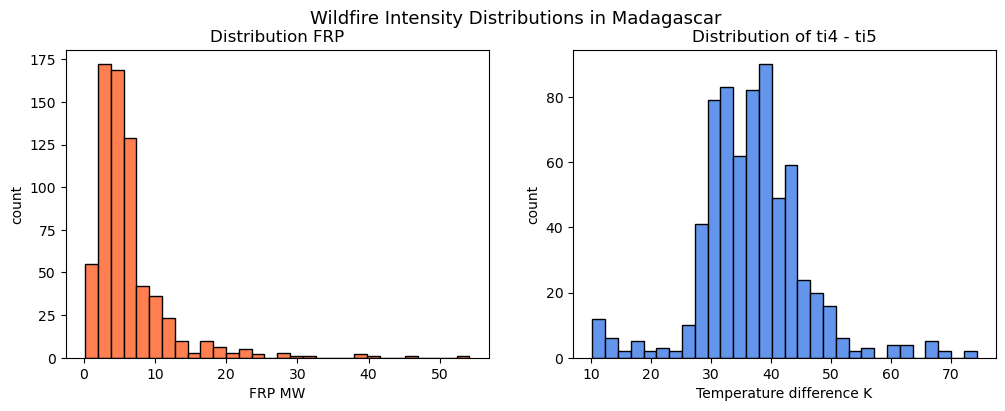

In [25]:
##histogramm
fig, axes = plt.subplots(1, 2, figsize =( 12, 4))

#distribution frp
axes[0].hist(fires_madagascar['frp'], bins = 30, color = 'coral', edgecolor = 'black')
axes[0].set_title('Distribution FRP')
axes[0].set_xlabel('FRP MW')
axes[0].set_ylabel('count')

#distribution temp_diff
axes[1].hist(fires_madagascar['temp_diff'], bins = 30, color = 'Cornflowerblue', edgecolor = 'black')
axes[1].set_title('Distribution of ti4 - ti5')
axes[1].set_xlabel('Temperature difference K')
axes[1].set_ylabel('count')

plt.suptitle('Wildfire Intensity Distributions in Madagascar', fontsize=13)
plt.show()

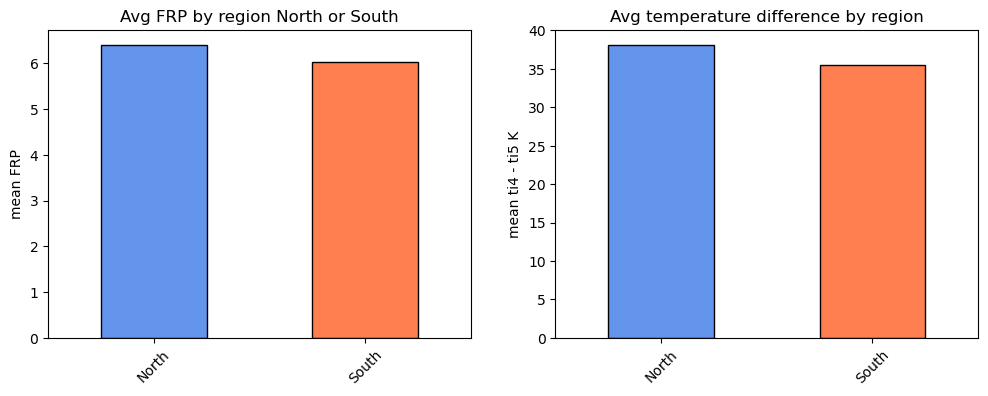

In [21]:
fig, axes = plt.subplots(1, 2, figsize =( 12, 4))

region_stats['frp'].plot(kind = 'bar', ax= axes[0], color = ['Cornflowerblue', 'coral'], edgecolor = 'black')
axes[0].set_title('Avg FRP by region North or South')
axes[0].set_xlabel('')
axes[0].set_ylabel('mean FRP')
axes[0].tick_params(axis="x", rotation=45)

region_stats['temp_diff'].plot(kind = 'bar', ax= axes[1], color = ['Cornflowerblue', 'coral'], edgecolor = 'black')
axes[1].set_title('Avg temperature difference by region')
axes[1].set_xlabel('')
axes[1].set_ylabel('mean ti4 - ti5 K')
axes[1].tick_params(axis="x", rotation=45)

In [22]:
#to get the center of Madagas.
center = madagascar.geometry.centroid.iloc[0]
center_lat = center.y
center_lon = center.x 

#!!!! wrong  need meters not degrees 


/var/folders/6l/h3f5hx216rs7vzxx_c82k8100000gn/T/ipykernel_98347/1882901278.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = madagascar.geometry.centroid.iloc[0]


In [23]:
madagascar_projected= madagascar.to_crs(epsg=32738)
center_projected= madagascar_projected.geometry.centroid.iloc[0]

center = gpd.GeoSeries([center_projected], crs=32738).to_crs(epsg=4326).iloc[0]
center_lat = center.y
center_lon = center.x 
print(center_lat, center_lon)

-19.314007703204048 46.74456026925646


In [37]:
#basemap
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=6,
    tiles="Esri.WorldImagery" # satellite basemap to shows real landscape: veg./terrain
)

#colormap as base temp_differece
td_colormap = cm.LinearColormap(
    colors = ['LightYellow', 'DarkOrange', 'FireBrick'],
    vmin = fires_madagascar['temp_diff'].quantile(0.05),
    vmax = fires_madagascar['temp_diff'].quantile(0.95),
    caption =  'ΔT = Ti4-Ti5 (K)')

frp_min = fires_madagascar['frp'].quantile(0.05)
frp_max = fires_madagascar['frp'].quantile(0.95) 

marker_cluster = MarkerCluster(name="Wildfire Clusters").add_to(m)

# 1. layer
# SIZE : how intense the fire is (FRP in MW)
# COLOR: how much hotter than surroundings (Ti4 - Ti5 in K)
fg_main = folium.FeatureGroup(name = "Intensity (size=FRP, color=temp_diff)", show=True)

fires_sorted = fires_madagascar.sort_values('frp', ascending=False)
    # largest frp first and smallest after-> smaller circler are on top of bigger ones
for _, row in fires_sorted.iterrows():
    radius = 3 + ((np.clip(row['frp'], frp_min, frp_max)-frp_min)/(frp_max-frp_min)) * 10 
    # np.clip(...): values stay btw 5% and 95%-> outliers do not distort scale = clipped
    # clipped-frp_min)/(frp_max-frp_min)-> min-max normalization: rescale val. btw 0-1
        # weakest fire = 0, strongest = 1, alle andere da zwischen
        # * 10 ändert scale von 0-1 zu 0-10pixel  und 3+ macht dass auch sehr kleine fires mind. raius von 3 pixel
                 
    folium.CircleMarker(
        location= [row['latitude'], row['longitude']],
        radius = radius,
        fill_color = td_colormap(row['temp_diff']),
        #give me the color that corresponds to the specific fire temp_diff value
        fill_opacity = 0.8,
        fill = True,
        color = 'black',
        weight = 0.25,
        #border : black but with thin lines
        tooltip = f"FRP: {row['frp']:.1f} (MW) | ΔT: {row['temp_diff']:.1f} (K)",
        popup = folium.Popup(
            f"FRP: {row['frp']:.1f} (MW)<br>"
            f"Temp. difference:</br>{row['temp_diff']:.1f} (K)<br>"
            f"Region:</br>{row['region']}"
        )
    ).add_to(marker_cluster)

td_colormap.add_to(m)
fg_main.add_to(m)


# 2. laver Heatmap
fg_heat = folium.FeatureGroup(name= "Fire density heatmap", show = False)
HeatMap(
    fires_madagascar[['latitude', 'longitude', 'frp']].values.tolist(),
    min_opacity = 0.4,
    radius = 13,
    blur = 9
).add_to(fg_heat)

fg_heat.add_to(m)

m 